## Import Packages

In [1]:
from pathlib import Path

import pyabf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.integrate import trapezoid

import ipywidgets as widgets
from IPython.display import display

sns.set_context("talk")
sns.set_style("whitegrid")


## Set folder paths

In [2]:
PROJECT = Path("/Volumes/My Passport for Mac/retina_project")

DATA_DIR = PROJECT / "data"
META_DIR = PROJECT / "metadata"
NOTEBOOK_DIR = PROJECT / "notebooks"
RESULTS_DIR = PROJECT / "results"
FIG_DIR = RESULTS_DIR / "figures"

META_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

print("Project folder:", PROJECT)
print("Data folder:", DATA_DIR)
print("Metadata folder:", META_DIR)
print("Results folder:", RESULTS_DIR)


Project folder: /Volumes/My Passport for Mac/retina_project
Data folder: /Volumes/My Passport for Mac/retina_project/data
Metadata folder: /Volumes/My Passport for Mac/retina_project/metadata
Results folder: /Volumes/My Passport for Mac/retina_project/results


## Create metadata table

In [3]:
META_FILE = META_DIR / "experiment_c2_26.05.14_metadata.csv"

metadata = pd.DataFrame([
    {
        "file": "2026_05_14_0039.abf",
        "drug": "control",
        "stimulus_type": "increasing_spot",
        "center_sf": np.nan,
        "surround_sf": np.nan,
        "sweeps": "0;1;2;3",
        "clamp_mV": -70,
        "stimID": 52,
        "notes": "200um biggest response"
    },
    {
        "file": "2026_05_14_0040.abf",
        "drug": "control",
        "stimulus_type": "center_only",
        "center_sf": 1,
        "surround_sf": 100,
        "sweeps": "0",
        "clamp_mV": -70,
        "stimID": 53,
        "notes": ""
    },
    {
        "file": "2026_05_14_0041.abf",
        "drug": "control",
        "stimulus_type": "center_surround",
        "center_sf": 1,
        "surround_sf": 1,
        "sweeps": "1",
        "clamp_mV": -70,
        "stimID": 56,
        "notes": ""
    },
    {
        "file": "2026_05_14_0042.abf",
        "drug": "control",
        "stimulus_type": "center_only",
        "center_sf": 1,
        "surround_sf": 100,
        "sweeps": "0",
        "clamp_mV": -70,
        "stimID": 57,
        "notes": ""
    },
    {
        "file": "2026_05_14_0043.abf",
        "drug": "control",
        "stimulus_type": "center_only",
        "center_sf": 1,
        "surround_sf": 100,
        "sweeps": "0",
        "clamp_mV": -70,
        "stimID": 58,
        "notes": ""
    },
    {
        "file": "2026_05_14_0044.abf",
        "drug": "control",
        "stimulus_type": "center_surround",
        "center_sf": 1,
        "surround_sf": 1,
        "sweeps": "0",
        "clamp_mV": -70,
        "stimID": 59,
        "notes": ""
    },
    {
        "file": "2026_05_14_0045.abf",
        "drug": "control",
        "stimulus_type": "center_surround",
        "center_sf": 1,
        "surround_sf": 4,
        "sweeps": "0",
        "clamp_mV": -70,
        "stimID": 60,
        "notes": ""
    },
    {
        "file": "2026_05_14_0047.abf",
        "drug": "control",
        "stimulus_type": "center_surround",
        "center_sf": 1,
        "surround_sf": 2,
        "sweeps": "0",
        "clamp_mV": -70,
        "stimID": 62,
        "notes": ""
    },
    {
        "file": "2026_05_14_0048.abf",
        "drug": "control",
        "stimulus_type": "center_surround",
        "center_sf": 1,
        "surround_sf": 8,
        "sweeps": "0",
        "clamp_mV": -70,
        "stimID": 63,
        "notes": ""
    },
    {
        "file": "2026_05_14_0049.abf",
        "drug": "control",
        "stimulus_type": "center_surround",
        "center_sf": 1,
        "surround_sf": 16,
        "sweeps": "0",
        "clamp_mV": -70,
        "stimID": 64,
        "notes": ""
    },
    {
        "file": "2026_05_14_0050.abf",
        "drug": "control",
        "stimulus_type": "center_surround",
        "center_sf": 1,
        "surround_sf": 0.5,
        "sweeps": "0",
        "clamp_mV": -70,
        "stimID": 65,
        "notes": ""
    },
    {
        "file": "2026_05_14_0051.abf",
        "drug": "control",
        "stimulus_type": "center_only",
        "center_sf": 1,
        "surround_sf": 100,
        "sweeps": "0",
        "clamp_mV": -70,
        "stimID": 66,
        "notes": ""
    },
    {
        "file": "2026_05_14_0054.abf",
        "drug": "control",
        "stimulus_type": "center_only",
        "center_sf": 1,
        "surround_sf": 100,
        "sweeps": "0",
        "clamp_mV": -70,
        "stimID": 69,
        "notes": ""
    },
    {
        "file": "2026_05_14_0055.abf",
        "drug": "control",
        "stimulus_type": "center_surround",
        "center_sf": 1,
        "surround_sf": 4,
        "sweeps": "0",
        "clamp_mV": -70,
        "stimID": 70,
        "notes": ""
    },
    {
        "file": "2026_05_14_0056.abf",
        "drug": "control",
        "stimulus_type": "center_surround",
        "center_sf": 1,
        "surround_sf": 2,
        "sweeps": "0",
        "clamp_mV": -70,
        "stimID": 71,
        "notes": ""
    },
    {
        "file": "2026_05_14_0057.abf",
        "drug": "control",
        "stimulus_type": "center_surround",
        "center_sf": 1,
        "surround_sf": 8,
        "sweeps": "0",
        "clamp_mV": -70,
        "stimID": 72,
        "notes": ""
    },
    {
        "file": "2026_05_14_0058.abf",
        "drug": "control",
        "stimulus_type": "center_surround",
        "center_sf": 1,
        "surround_sf": 4,
        "sweeps": "0",
        "clamp_mV": -70,
        "stimID": 73,
        "notes": ""
    },
    {
        "file": "2026_05_14_0059.abf",
        "drug": "control",
        "stimulus_type": "center_surround",
        "center_sf": 1,
        "surround_sf": 4,
        "sweeps": "0",
        "clamp_mV": -70,
        "stimID": 53,
        "notes": ""
    },
    {
        "file": "2026_05_14_0060.abf",
        "drug": "control",
        "stimulus_type": "center_only",
        "center_sf": 1,
        "surround_sf": 100,
        "sweeps": "0",
        "clamp_mV": -70,
        "stimID": 75,
        "notes": ""
    },
    {
        "file": "2026_05_14_0062.abf",
        "drug": "control",
        "stimulus_type": "center_surround",
        "center_sf": 1,
        "surround_sf": 2,
        "sweeps": "0",
        "clamp_mV": -70,
        "stimID": 77,
        "notes": ""
    },
    {
        "file": "2026_05_14_0063.abf",
        "drug": "control",
        "stimulus_type": "center_surround",
        "center_sf": 1,
        "surround_sf": 0.5,
        "sweeps": "0",
        "clamp_mV": -70,
        "stimID": 78,
        "notes": ""
    },
    {
        "file": "2026_05_14_0064.abf",
        "drug": "control",
        "stimulus_type": "center_only",
        "center_sf": 1,
        "surround_sf": 100,
        "sweeps": "0",
        "clamp_mV": -70,
        "stimID": 79,
        "notes": ""
    },
    {
        "file": "2026_05_14_0065.abf",
        "drug": "control",
        "stimulus_type": "center_surround",
        "center_sf": 1,
        "surround_sf": 4,
        "sweeps": "0",
        "clamp_mV": -70,
        "stimID": 80,
        "notes": ""
    },
    {
        "file": "2026_05_14_0066.abf",
        "drug": "control",
        "stimulus_type": "center_surround",
        "center_sf": 1,
        "surround_sf": 4,
        "sweeps": "0",
        "clamp_mV": -70,
        "notes": ""
    },
    {
        "file": "2026_05_14_0069.abf",
        "drug": "control",
        "stimulus_type": "center_surround",
        "center_sf": 1,
        "surround_sf": 4,
        "sweeps": "0;1",
        "clamp_mV": -70,
        "notes": ""
    },
    {
        "file": "2026_05_14_0070.abf",
        "drug": "ttx",
        "stimulus_type": "center_surround",
        "center_sf": 1,
        "surround_sf": 4,
        "sweeps": "6;7;8;9;10;11",
        "clamp_mV": -70,
        "notes": ""
    },
    {
        "file": "2026_05_14_0071.abf",
        "drug": "ttx",
        "stimulus_type": "center_only",
        "center_sf": 1,
        "surround_sf": 100,
        "sweeps": "0;1;2",
        "clamp_mV": -70,
        "notes": ""
    },
    {
        "file": "2026_05_14_0072.abf",
        "drug": "ttx",
        "stimulus_type": "center_only",
        "center_sf": 1,
        "surround_sf": 100,
        "sweeps": "0",
        "clamp_mV": -70,
        "notes": ""
    }
        
])

metadata.to_csv(META_FILE, index=False)
metadata


,file,drug,stimulus_type,center_sf,surround_sf,sweeps,clamp_mV,stimID,notes
0,2026_05_14_0039.abf,control,increasing_spot,NaN,NaN,0;1;2;3,-70,52.0,200um biggest response
1,2026_05_14_0040.abf,control,center_only,1.0,100.0,0,-70,53.0,
2,2026_05_14_0041.abf,control,center_surround,1.0,1.0,1,-70,56.0,
3,2026_05_14_0042.abf,control,center_only,1.0,100.0,0,-70,57.0,
4,2026_05_14_0043.abf,control,center_only,1.0,100.0,0,-70,58.0,
5,2026_05_14_0044.abf,control,center_surround,1.0,1.0,0,-70,59.0,
6,2026_05_14_0045.abf,control,center_surround,1.0,4.0,0,-70,60.0,
7,2026_05_14_0047.abf,control,center_surround,1.0,2.0,0,-70,62.0,
8,2026_05_14_0048.abf,control,center_surround,1.0,8.0,0,-70,63.0,
9,2026_05_14_0049.abf,control,center_surround,1.0,16.0,0,-70,64.0,


## Load Metadata

In [4]:
META_FILE = META_DIR / "experiment_c2_26.05.14_metadata.csv"

metadata = pd.read_csv(META_FILE)

metadata


,file,drug,stimulus_type,center_sf,surround_sf,sweeps,clamp_mV,stimID,notes
0,2026_05_14_0039.abf,control,increasing_spot,NaN,NaN,0;1;2;3,-70,52.0,200um biggest response
1,2026_05_14_0040.abf,control,center_only,1.0,100.0,0,-70,53.0,NaN
2,2026_05_14_0041.abf,control,center_surround,1.0,1.0,1,-70,56.0,NaN
3,2026_05_14_0042.abf,control,center_only,1.0,100.0,0,-70,57.0,NaN
4,2026_05_14_0043.abf,control,center_only,1.0,100.0,0,-70,58.0,NaN
5,2026_05_14_0044.abf,control,center_surround,1.0,1.0,0,-70,59.0,NaN
6,2026_05_14_0045.abf,control,center_surround,1.0,4.0,0,-70,60.0,NaN
7,2026_05_14_0047.abf,control,center_surround,1.0,2.0,0,-70,62.0,NaN
8,2026_05_14_0048.abf,control,center_surround,1.0,8.0,0,-70,63.0,NaN
9,2026_05_14_0049.abf,control,center_surround,1.0,16.0,0,-70,64.0,NaN


## Define helper functions to load ABF files

In [5]:
def parse_sweeps(sweep_string):
    """
    Converts a sweep string like '0;1;2' into a list: [0, 1, 2].
    """
    return [int(s.strip()) for s in str(sweep_string).split(";")]


def load_sweeps(file_name, sweeps):
    """
    Loads multiple sweeps from one ABF file.

    Parameters
    ----------
    file_name : str
        Name of the ABF file.
    sweeps : list
        List of sweep numbers, for example [0, 1, 2].

    Returns
    -------
    time : array
        Time values in seconds.
    traces : array
        Shape is number of sweeps x number of timepoints.
    """

    file_path = DATA_DIR / file_name

    if not file_path.exists():
        raise FileNotFoundError(f"Could not find file: {file_path}")

    abf = pyabf.ABF(str(file_path))

    traces = []
    time = None

    for sweep in sweeps:
        abf.setSweep(int(sweep))

        if time is None:
            time = abf.sweepX

        traces.append(abf.sweepY)

    traces = np.array(traces)

    return time, traces


## load and plot one file's three sweeps

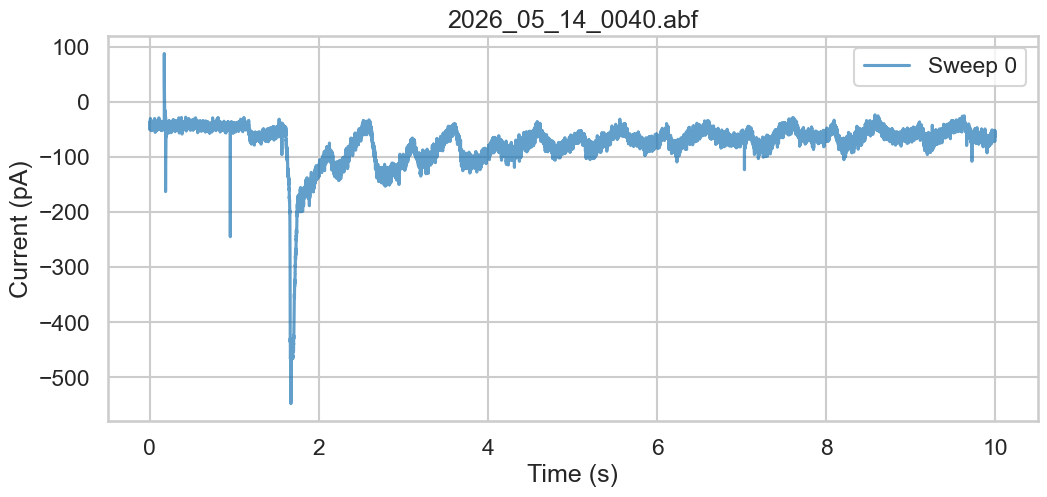

In [6]:
test_file = metadata.loc[1, "file"]
test_sweeps = parse_sweeps(metadata.loc[1, "sweeps"])

time, traces = load_sweeps(test_file, test_sweeps)

plt.figure(figsize=(12, 5))

for sweep_number, trace in zip(test_sweeps, traces):
    plt.plot(time, trace, alpha=0.7, label=f"Sweep {sweep_number}")

plt.xlabel("Time (s)")
plt.ylabel("Current (pA)")
plt.title(test_file)
plt.legend()
plt.show()


## Baseline-subtract each sweep

In [7]:
def baseline_subtract_traces(time, traces, baseline_window=(0.2, 1.0)):
    """
    Baseline-subtracts each sweep independently.

    Parameters
    ----------
    time : array
        Time values.
    traces : array
        Shape is number of sweeps x number of timepoints.
    baseline_window : tuple
        Start and end of baseline window in seconds.

    Returns
    -------
    corrected_traces : array
        Baseline-subtracted traces.
    baselines : array
        Baseline mean for each sweep.
    """

    baseline_mask = (time >= baseline_window[0]) & (time <= baseline_window[1])

    corrected_traces = []
    baselines = []

    for trace in traces:
        baseline = np.mean(trace[baseline_mask])
        baselines.append(baseline)
        corrected_traces.append(trace - baseline)

    corrected_traces = np.array(corrected_traces)
    baselines = np.array(baselines)

    return corrected_traces, baselines


In [8]:
baseline_window = (0.2, 1.0)

corrected_traces, baselines = baseline_subtract_traces(
    time,
    traces,
    baseline_window=baseline_window
)

print("Baseline values for each sweep:", baselines)


Baseline values for each sweep: [-43.7663]


## Average the baseline-subtracted sweeps

In [9]:
def average_baseline_corrected_sweeps(
    file_name,
    sweeps,
    baseline_window=(0.2, 1.0)
):
    """
    Loads sweeps, baseline-subtracts each sweep, then averages them.
    """

    time, traces = load_sweeps(file_name, sweeps)

    corrected_traces, baselines = baseline_subtract_traces(
        time,
        traces,
        baseline_window=baseline_window
    )

    average_trace = np.mean(corrected_traces, axis=0)

    return time, corrected_traces, average_trace, baselines


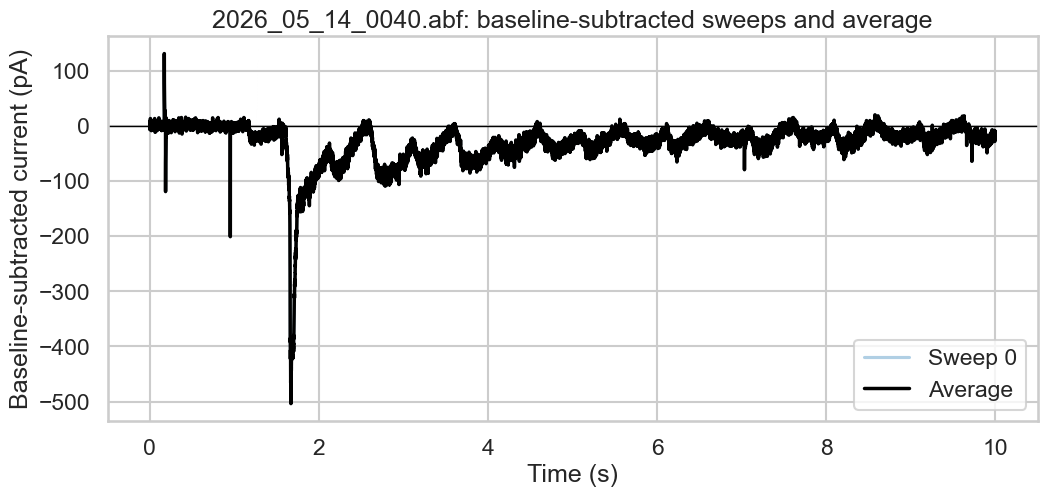

In [10]:
time, corrected_traces, average_trace, baselines = average_baseline_corrected_sweeps(
    test_file,
    test_sweeps,
    baseline_window=(0.2, 1.0)
)

plt.figure(figsize=(12, 5))

for sweep_number, trace in zip(test_sweeps, corrected_traces):
    plt.plot(time, trace, alpha=0.35, label=f"Sweep {sweep_number}")

plt.plot(time, average_trace, color="black", lw=2.5, label="Average")

plt.axhline(0, color="black", lw=1)
plt.xlabel("Time (s)")
plt.ylabel("Baseline-subtracted current (pA)")
plt.title(f"{test_file}: baseline-subtracted sweeps and average")
plt.legend()
plt.show()


## Make a reusable plotting function 

In [11]:
def plot_condition_average(
    file_name,
    sweeps,
    baseline_window=(0.2, 1.0),
    stim_window=(2, 10.0),
    title=None
):
    """
    Plots individual baseline-subtracted sweeps and their average.
    """

    time, corrected_traces, average_trace, baselines = average_baseline_corrected_sweeps(
        file_name,
        sweeps,
        baseline_window=baseline_window
    )

    plt.figure(figsize=(12, 5))

    for sweep_number, trace in zip(sweeps, corrected_traces):
        plt.plot(time, trace, alpha=0.35, lw=1, label=f"Sweep {sweep_number}")

    plt.plot(time, average_trace, color="black", lw=2.5, label="Average")

    plt.axvspan(
        baseline_window[0],
        baseline_window[1],
        color="gray",
        alpha=0.15,
        label="baseline"
    )

    plt.axvspan(
        stim_window[0],
        stim_window[1],
        color="orange",
        alpha=0.15,
        label="stimulus"
    )

    plt.axhline(0, color="black", lw=1)

    plt.xlabel("Time (s)")
    plt.ylabel("Baseline-subtracted current (pA)")

    if title is None:
        title = f"{file_name}, sweeps {sweeps}"

    plt.title(title)
    plt.legend()
    plt.show()


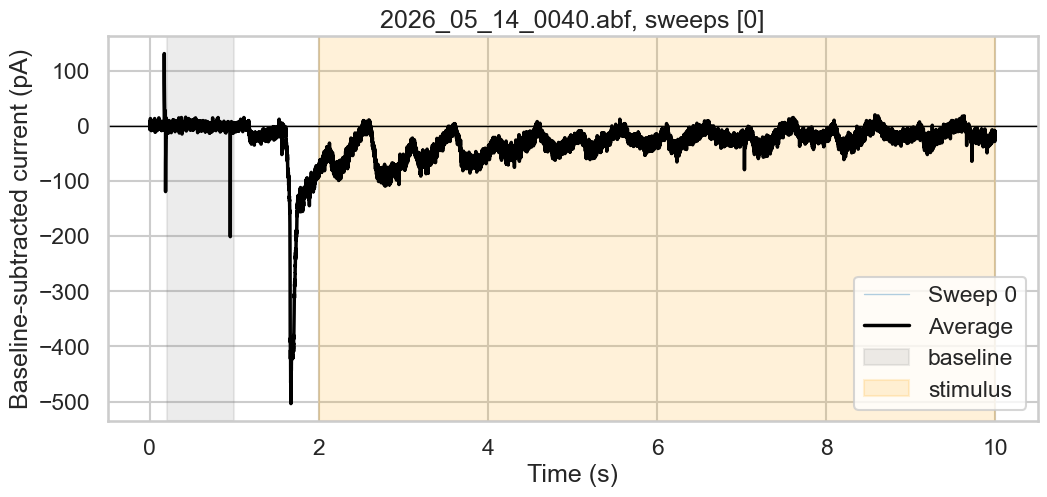

In [12]:
plot_condition_average(
    file_name=test_file,
    sweeps=test_sweeps,
    baseline_window=(0.2, 1.0),
    stim_window=(2, 10.0)
)


## Add interactive viewer

In [13]:
file_dropdown = widgets.Dropdown(
    options=metadata["file"].tolist(),
    description="File:",
    layout=widgets.Layout(width="400px")
)

baseline_start_widget = widgets.FloatText(value=0.2, description="Base start")
baseline_end_widget = widgets.FloatText(value=1.0, description="Base end")

stim_start_widget = widgets.FloatText(value=1.2, description="Stim start")
stim_end_widget = widgets.FloatText(value=10.0, description="Stim end")


def interactive_average_plot(file_name, b0, b1, s0, s1):
    row = metadata[metadata["file"] == file_name].iloc[0]
    sweeps = parse_sweeps(row["sweeps"])

    title = (
        f"{file_name} | {row['drug']} | {row['stimulus_type']} | "
        f"center SF={row['center_sf']} | surround SF={row['surround_sf']}"
    )

    plot_condition_average(
        file_name=file_name,
        sweeps=sweeps,
        baseline_window=(b0, b1),
        stim_window=(s0, s1),
        title=title
    )


widgets.interact(
    interactive_average_plot,
    file_name=file_dropdown,
    b0=baseline_start_widget,
    b1=baseline_end_widget,
    s0=stim_start_widget,
    s1=stim_end_widget
);


interactive(children=(Dropdown(description='File:', layout=Layout(width='400px'), options=('2026_05_14_0039.ab…

## Define response windows

In [14]:
baseline_window = (0.2, 1.0)
stim_window = (2, 10.0)
early_window = (2, 3)
late_window = (3, 10.0)


## Analyze one trace

In [15]:
def analyze_trace(
    time,
    trace,
    stim_window=(2, 10.0),
    early_window=(2, 3),
    late_window=(3, 10.0),
    artifact_threshold_pA=500
):
    """
    Analyzes a baseline-subtracted trace.

    Because the trace is already baseline-subtracted:
    - baseline is approximately 0
    - inward currents at -70 mV are negative
    """

    stim_mask = (time >= stim_window[0]) & (time <= stim_window[1])
    early_mask = (time >= early_window[0]) & (time <= early_window[1])
    late_mask = (time >= late_window[0]) & (time <= late_window[1])

    stim_current = trace[stim_mask]
    stim_time = time[stim_mask]

    early_current = trace[early_mask]
    late_current = trace[late_mask]

    cleaned_stim = stim_current.copy()
    cleaned_stim[np.abs(cleaned_stim) > artifact_threshold_pA] = np.nan

    peak_inward = np.nanmin(cleaned_stim)
    peak_outward = np.nanmax(cleaned_stim)

    mean_response = np.nanmean(cleaned_stim)
    early_mean_response = np.nanmean(early_current)
    late_mean_response = np.nanmean(late_current)

    charge_transfer = trapezoid(stim_current, stim_time)

    return {
        "peak_inward_pA": peak_inward,
        "peak_outward_pA": peak_outward,
        "mean_response_pA": mean_response,
        "early_mean_response_pA": early_mean_response,
        "late_mean_response_pA": late_mean_response,
        "charge_transfer_pA_s": charge_transfer
    }


## Analyze individual sweeps and the averaged trace
It will produce
- one row for sweep 0
- one row for sweep 1
- one row for sweep 2
- one row for the average trace

In [16]:
def analyze_condition_row(
    row,
    baseline_window=(0.2, 1.0),
    stim_window=(2, 10.0),
    early_window=(2, 3),
    late_window=(3, 10.0),
    artifact_threshold_pA=500
):
    """
    Analyzes all sweeps for one stimulus condition.

    Each metadata row represents one condition/file.
    """

    file_name = row["file"]
    sweeps = parse_sweeps(row["sweeps"])

    time, corrected_traces, average_trace, baselines = average_baseline_corrected_sweeps(
        file_name,
        sweeps,
        baseline_window=baseline_window
    )

    output_rows = []

    # Analyze individual sweeps
    for sweep_number, trace, baseline in zip(sweeps, corrected_traces, baselines):
        result = analyze_trace(
            time=time,
            trace=trace,
            stim_window=stim_window,
            early_window=early_window,
            late_window=late_window,
            artifact_threshold_pA=artifact_threshold_pA
        )

        output = row.to_dict()
        output.update(result)

        output["analysis_level"] = "individual_sweep"
        output["sweep"] = sweep_number
        output["baseline_mean_pA"] = baseline
        output["n_sweeps_averaged"] = 1

        output_rows.append(output)

    # Analyze averaged trace
    avg_result = analyze_trace(
        time=time,
        trace=average_trace,
        stim_window=stim_window,
        early_window=early_window,
        late_window=late_window,
        artifact_threshold_pA=artifact_threshold_pA
    )

    output = row.to_dict()
    output.update(avg_result)

    output["analysis_level"] = "average_trace"
    output["sweep"] = "avg"
    output["baseline_mean_pA"] = np.mean(baselines)
    output["n_sweeps_averaged"] = len(sweeps)

    output_rows.append(output)

    return output_rows


## Analyze the whole experiment
everything is multiplied by -1 because at -70mV, excitatory inward currents are negative. Turning them positive makes graphs easier to interpret: bigger response = higher value

In [17]:
all_results = []

for _, row in metadata.iterrows():
    condition_results = analyze_condition_row(
        row,
        baseline_window=baseline_window,
        stim_window=stim_window,
        early_window=early_window,
        late_window=late_window,
        artifact_threshold_pA=500
    )

    all_results.extend(condition_results)

results = pd.DataFrame(all_results)

results["inward_mean_response_pA"] = -results["mean_response_pA"]
results["inward_peak_response_pA"] = -results["peak_inward_pA"]
results["inward_late_response_pA"] = -results["late_mean_response_pA"]
results["inward_early_response_pA"] = -results["early_mean_response_pA"]
results["inward_charge_pA_s"] = -results["charge_transfer_pA_s"]

results


,file,drug,stimulus_type,center_sf,surround_sf,sweeps,clamp_mV,stimID,notes,peak_inward_pA,...,charge_transfer_pA_s,analysis_level,sweep,baseline_mean_pA,n_sweeps_averaged,inward_mean_response_pA,inward_peak_response_pA,inward_late_response_pA,inward_early_response_pA,inward_charge_pA_s
0,2026_05_14_0039.abf,control,increasing_spot,NaN,NaN,0;1;2;3,-70,52.0,200um biggest response,-75.024429,...,-4.806958,individual_sweep,0,-38.500961,1,0.600887,75.024429,-0.972580,11.612395,4.806958
1,2026_05_14_0039.abf,control,increasing_spot,NaN,NaN,0;1;2;3,-70,52.0,200um biggest response,-136.400894,...,-25.631208,individual_sweep,1,-38.770004,1,3.204102,136.400894,1.776718,13.195764,25.631208
2,2026_05_14_0039.abf,control,increasing_spot,NaN,NaN,0;1;2;3,-70,52.0,200um biggest response,-146.400482,...,3.845058,individual_sweep,2,-45.860264,1,-0.480358,146.400482,-1.793557,8.709376,-3.845058
3,2026_05_14_0039.abf,control,increasing_spot,NaN,NaN,0;1;2;3,-70,52.0,200um biggest response,-120.646729,...,-18.350454,individual_sweep,3,-42.927490,1,2.293857,120.646729,2.346667,1.923968,18.350454
4,2026_05_14_0039.abf,control,increasing_spot,NaN,NaN,0;1;2;3,-70,52.0,200um biggest response,-38.899139,...,-11.235893,average_trace,avg,-41.514679,4,1.404622,38.899139,0.339312,8.860376,11.235893
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,2026_05_14_0071.abf,ttx,center_only,1.0,100.0,0;1;2,-70,NaN,NaN,-108.744209,...,-27.176018,individual_sweep,1,-67.037041,1,3.397320,108.744209,2.955483,6.491024,27.176018
63,2026_05_14_0071.abf,ttx,center_only,1.0,100.0,0;1;2,-70,NaN,NaN,-96.692390,...,-21.648499,individual_sweep,2,-66.271477,1,2.706108,96.692390,2.423243,4.686889,21.648499
64,2026_05_14_0071.abf,ttx,center_only,1.0,100.0,0;1;2,-70,NaN,NaN,-37.708836,...,-24.085665,average_trace,avg,-68.085442,3,3.010914,37.708836,2.544185,6.278704,24.085665
65,2026_05_14_0072.abf,ttx,center_only,1.0,100.0,0,-70,NaN,NaN,-171.435944,...,-38.469059,individual_sweep,0,-69.652916,1,4.809421,171.435944,3.934687,10.933930,38.469059


## Save Results

In [18]:
RESULTS_FILE = RESULTS_DIR / "response_summary_c2_26.05.14.csv"

results.to_csv(RESULTS_FILE, index=False)

print("Saved results to:", RESULTS_FILE)


Saved results to: /Volumes/My Passport for Mac/retina_project/results/response_summary_c2_26.05.14.csv


## Separate individual sweeps from average traces

In [19]:
individual_results = results[results["analysis_level"] == "individual_sweep"].copy()
average_results = results[results["analysis_level"] == "average_trace"].copy()

average_results


,file,drug,stimulus_type,center_sf,surround_sf,sweeps,clamp_mV,stimID,notes,peak_inward_pA,...,charge_transfer_pA_s,analysis_level,sweep,baseline_mean_pA,n_sweeps_averaged,inward_mean_response_pA,inward_peak_response_pA,inward_late_response_pA,inward_early_response_pA,inward_charge_pA_s
4,2026_05_14_0039.abf,control,increasing_spot,NaN,NaN,0;1;2;3,-70,52.0,200um biggest response,-38.899139,...,-11.235893,average_trace,avg,-41.514679,4,1.404622,38.899139,0.339312,8.860376,11.235893
6,2026_05_14_0040.abf,control,center_only,1.0,100.0,0,-70,53.0,NaN,-109.431976,...,-238.380936,average_trace,avg,-43.766270,1,29.799063,109.431976,25.805067,57.759872,238.380936
8,2026_05_14_0041.abf,control,center_surround,1.0,1.0,1,-70,56.0,NaN,-96.082603,...,-33.628277,average_trace,avg,-30.870520,1,4.203657,96.082603,4.293948,3.569875,33.628277
10,2026_05_14_0042.abf,control,center_only,1.0,100.0,0,-70,57.0,NaN,-117.623955,...,-140.392548,average_trace,avg,-31.912176,1,17.549934,117.623955,16.384552,25.707394,140.392548
12,2026_05_14_0043.abf,control,center_only,1.0,100.0,0,-70,58.0,NaN,-71.916420,...,-128.607086,average_trace,avg,-30.622641,1,16.076273,71.916420,14.979580,23.753262,128.607086
14,2026_05_14_0044.abf,control,center_surround,1.0,1.0,0,-70,59.0,NaN,-123.970581,...,-36.519974,average_trace,avg,-26.175901,1,4.564988,123.970581,4.593904,4.361508,36.519974
16,2026_05_14_0045.abf,control,center_surround,1.0,4.0,0,-70,60.0,NaN,-123.990799,...,-112.748550,average_trace,avg,-26.155689,1,14.093888,123.990799,14.292725,12.702702,112.748550
18,2026_05_14_0047.abf,control,center_surround,1.0,2.0,0,-70,62.0,NaN,-182.612198,...,-100.296082,average_trace,avg,-25.517691,1,12.537310,182.612198,12.801793,10.684805,100.296082
20,2026_05_14_0048.abf,control,center_surround,1.0,8.0,0,-70,63.0,NaN,-116.452827,...,-173.423126,average_trace,avg,-27.590139,1,21.678734,116.452827,20.689083,28.610712,173.423126
22,2026_05_14_0049.abf,control,center_surround,1.0,16.0,0,-70,64.0,NaN,-259.674377,...,-221.014954,average_trace,avg,-26.580515,1,27.628851,259.674377,24.419657,50.095566,221.014954


### For final tuning curves use: average results
### For checking variability use: individual_results

## Plot center-only spatial frequency tuning

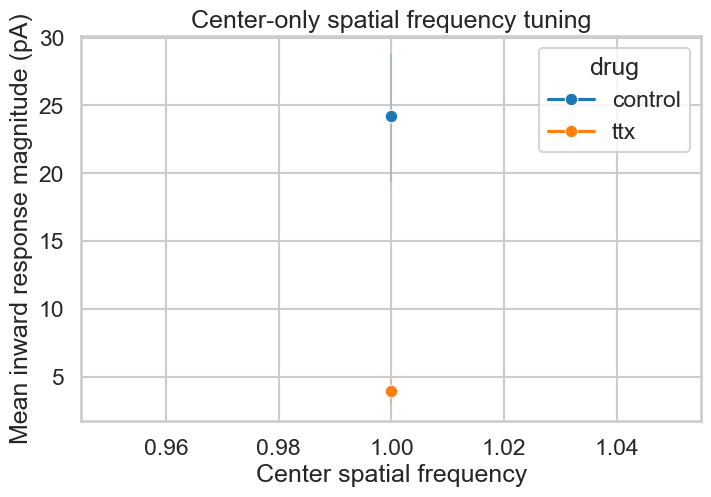

In [20]:
df = average_results[average_results["stimulus_type"] == "center_only"].copy()

plt.figure(figsize=(8, 5))

sns.lineplot(
    data=df,
    x="center_sf",
    y="inward_mean_response_pA",
    hue="drug",
    marker="o"
)

plt.xlabel("Center spatial frequency")
plt.ylabel("Mean inward response magnitude (pA)")
plt.title("Center-only spatial frequency tuning")
plt.show()


## Plot center+surround spatial frequency tuning

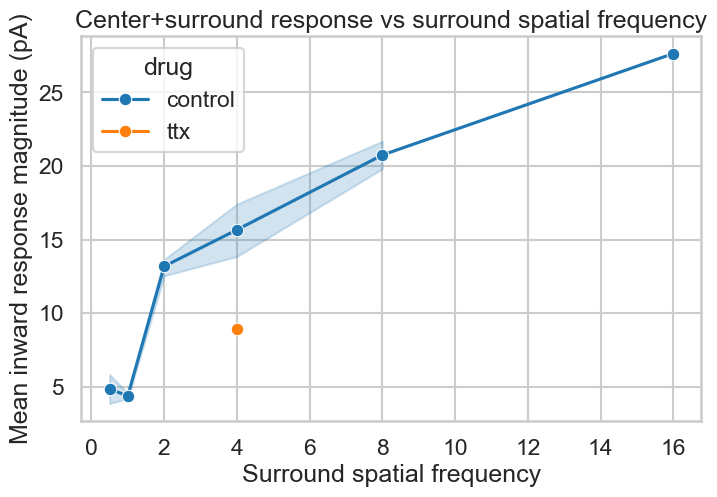

In [21]:
df = average_results[average_results["stimulus_type"] == "center_surround"].copy()

plt.figure(figsize=(8, 5))

sns.lineplot(
    data=df,
    x="surround_sf",
    y="inward_mean_response_pA",
    hue="drug",
    marker="o"
)

plt.xlabel("Surround spatial frequency")
plt.ylabel("Mean inward response magnitude (pA)")
plt.title("Center+surround response vs surround spatial frequency")
plt.show()


## Plot control vs TTX at one condition 

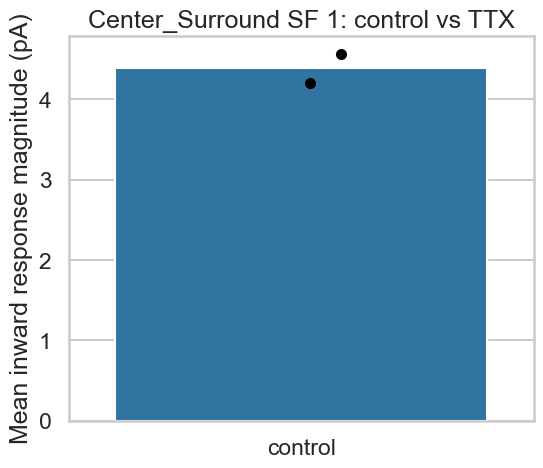

In [22]:
df = average_results[
    (average_results["stimulus_type"] == "center_surround") &
    (average_results["surround_sf"] == 1)
].copy()

plt.figure(figsize=(6, 5))

sns.barplot(
    data=df,
    x="drug",
    y="inward_mean_response_pA",
    errorbar=None
)

sns.stripplot(
    data=df,
    x="drug",
    y="inward_mean_response_pA",
    color="black",
    size=8
)

plt.xlabel("")
plt.ylabel("Mean inward response magnitude (pA)")
plt.title("Center_Surround SF 1: control vs TTX")
plt.show()


## Show individual sweep variability 

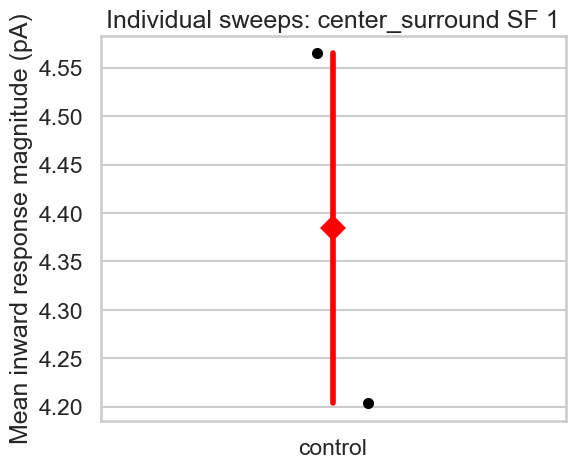

In [23]:
df = individual_results[
    (individual_results["stimulus_type"] == "center_surround") &
    (individual_results["surround_sf"] == 1)
].copy()

plt.figure(figsize=(6, 5))

sns.stripplot(
    data=df,
    x="drug",
    y="inward_mean_response_pA",
    color="black",
    size=8,
    jitter=True
)

sns.pointplot(
    data=df,
    x="drug",
    y="inward_mean_response_pA",
    errorbar="se",
    color="red",
    markers="D"
)

plt.xlabel("")
plt.ylabel("Mean inward response magnitude (pA)")
plt.title("Individual sweeps: center_surround SF 1")
plt.show()


## Overlay control and TTX average traces

In [24]:
def get_average_trace_for_row(row, baseline_window=(0.2, 1.0)):

    sweeps = parse_sweeps(row["sweeps"])

    time, corrected_traces, average_trace, baselines = average_baseline_corrected_sweeps(
        row["file"],
        sweeps,
        baseline_window=baseline_window
    )

    return time, average_trace


def overlay_average_traces(
    metadata,
    stimulus_type,
    center_sf=None,
    surround_sf=None,
    baseline_window=(0.2, 1.0),
    stim_window=(1.05, 10.0),
    exclude_files=None
):

    df = metadata[metadata["stimulus_type"] == stimulus_type].copy()

    if center_sf is not None:
        df = df[df["center_sf"] == center_sf]

    if surround_sf is not None:
        df = df[df["surround_sf"] == surround_sf]

    # ---------- EXCLUDE FILES ----------
    if exclude_files is not None:
        df = df[~df["file"].isin(exclude_files)]

    plt.figure(figsize=(12, 5))

    for _, row in df.iterrows():

        time, average_trace = get_average_trace_for_row(
            row,
            baseline_window=baseline_window
        )

        label = f"{row['drug']} | {row['file']}"

        plt.plot(
            time,
            average_trace,
            lw=2,
            label=label
        )

    plt.axvspan(
        stim_window[0],
        stim_window[1],
        color="orange",
        alpha=0.15,
        label="stimulus"
    )

    plt.axhline(0, color="black", lw=1)

    plt.xlabel("Time (s)")
    plt.ylabel("Baseline-subtracted current (pA)")

    plt.title(
        f"{stimulus_type}, center SF={center_sf}, surround SF={surround_sf}"
    )

    plt.legend()
    plt.show()


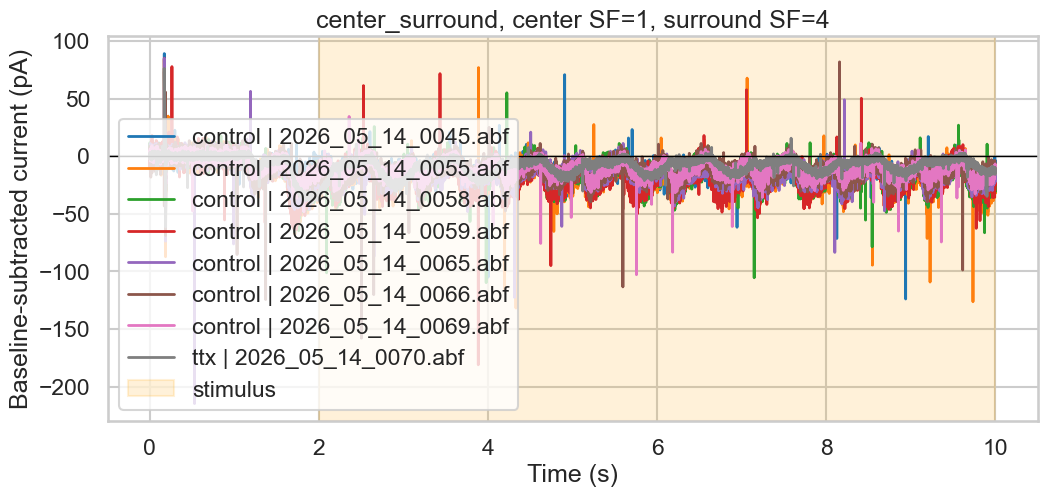

In [25]:
overlay_average_traces(
    metadata,
    stimulus_type="center_surround",
    center_sf=1,
    surround_sf=4,
    baseline_window=baseline_window,
    stim_window=stim_window,

   # exclude_files=[
    
   # ]
)


In [26]:
def overlay_center_vs_center_surround(
    metadata,
    drug="control",
    center_sf=1,
    surround_sf=1,
    baseline_window=(0.2, 1.0),
    stim_window=(2, 10.0),
    exclude_files=None
):

    df = metadata[
        (metadata["drug"] == drug) &
        (
            (
                (metadata["stimulus_type"] == "center_only") &
                (metadata["center_sf"] == center_sf)
            )
            |
            (
                (metadata["stimulus_type"] == "center_surround") &
                (metadata["center_sf"] == center_sf) &
                (metadata["surround_sf"] == surround_sf)
            )
        )
    ].copy()

    # ---------- EXCLUDE FILES ----------
    if exclude_files is not None:
        df = df[~df["file"].isin(exclude_files)]

    plt.figure(figsize=(12, 5))

    for _, row in df.iterrows():

        time, average_trace = get_average_trace_for_row(
            row,
            baseline_window=baseline_window
        )

        label = f"{row['stimulus_type']} | {row['file']}"

        plt.plot(
            time,
            average_trace,
            lw=2,
            label=label
        )

    plt.axvspan(
        stim_window[0],
        stim_window[1],
        color="orange",
        alpha=0.15,
        label="stimulus"
    )

    plt.axhline(0, color="black", lw=1)

    plt.xlabel("Time (s)")
    plt.ylabel("Baseline-subtracted current (pA)")

    plt.title(
        f"{drug}: center_only vs center_surround | "
        f"center SF={center_sf}, surround SF={surround_sf}"
    )

    plt.legend()
    plt.show()

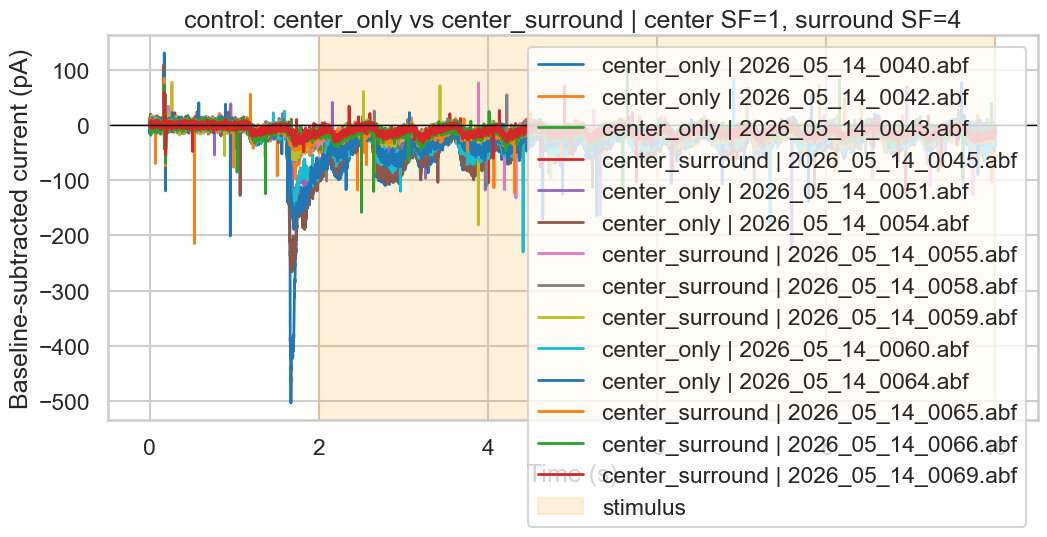

In [27]:
overlay_center_vs_center_surround(
    metadata,
    drug="control",
    center_sf=1,
    surround_sf=4,
    baseline_window=baseline_window,
    stim_window=stim_window,

    # exclude_files=[
    #     "2026_05_12_0046.abf",
    #     "2026_05_12_0049.abf"
    # ]
)

## Calculate surround modulation index

SMI = (Rc+s - Rc) / (Rc+s + Rc)

In [28]:
def calculate_smi(average_results, response_column="inward_mean_response_pA"):
    """
    Calculates surround modulation index for center+surround rows.

    This assumes matching center_only rows exist for the same:
    - drug
    - center_sf
    """

    center_only = average_results[
        average_results["stimulus_type"] == "center_only"
    ].copy()

    center_surround = average_results[
        average_results["stimulus_type"] == "center_surround"
    ].copy()

    smi_rows = []

    for _, cs_row in center_surround.iterrows():
        matching_center = center_only[
            (center_only["drug"] == cs_row["drug"]) &
            (center_only["center_sf"] == cs_row["center_sf"])
        ]

        if len(matching_center) == 0:
            continue

        r_center = matching_center.iloc[0][response_column]
        r_cs = cs_row[response_column]

        smi = (r_cs - r_center) / (r_cs + r_center)

        output = cs_row.to_dict()
        output["R_center"] = r_center
        output["R_center_surround"] = r_cs
        output["SMI"] = smi

        smi_rows.append(output)

    return pd.DataFrame(smi_rows)


In [29]:
smi_results = calculate_smi(
    average_results,
    response_column="inward_mean_response_pA"
)

smi_results


,file,drug,stimulus_type,center_sf,surround_sf,sweeps,clamp_mV,stimID,notes,peak_inward_pA,...,baseline_mean_pA,n_sweeps_averaged,inward_mean_response_pA,inward_peak_response_pA,inward_late_response_pA,inward_early_response_pA,inward_charge_pA_s,R_center,R_center_surround,SMI
0,2026_05_14_0041.abf,control,center_surround,1.0,1.0,1,-70,56.0,NaN,-96.082603,...,-30.870520,1,4.203657,96.082603,4.293948,3.569875,33.628277,29.799063,4.203657,-0.752746
1,2026_05_14_0044.abf,control,center_surround,1.0,1.0,0,-70,59.0,NaN,-123.970581,...,-26.175901,1,4.564988,123.970581,4.593904,4.361508,36.519974,29.799063,4.564988,-0.734316
2,2026_05_14_0045.abf,control,center_surround,1.0,4.0,0,-70,60.0,NaN,-123.990799,...,-26.155689,1,14.093888,123.990799,14.292725,12.702702,112.748550,29.799063,14.093888,-0.357806
3,2026_05_14_0047.abf,control,center_surround,1.0,2.0,0,-70,62.0,NaN,-182.612198,...,-25.517691,1,12.537310,182.612198,12.801793,10.684805,100.296082,29.799063,12.537310,-0.407729
4,2026_05_14_0048.abf,control,center_surround,1.0,8.0,0,-70,63.0,NaN,-116.452827,...,-27.590139,1,21.678734,116.452827,20.689083,28.610712,173.423126,29.799063,21.678734,-0.157744
5,2026_05_14_0049.abf,control,center_surround,1.0,16.0,0,-70,64.0,NaN,-259.674377,...,-26.580515,1,27.628851,259.674377,24.419657,50.095566,221.014954,29.799063,27.628851,-0.037790
6,2026_05_14_0050.abf,control,center_surround,1.0,0.5,0,-70,65.0,NaN,-121.047722,...,-27.267710,1,3.863654,121.047722,3.876569,3.773420,30.909637,29.799063,3.863654,-0.770449
7,2026_05_14_0055.abf,control,center_surround,1.0,4.0,0,-70,70.0,NaN,-131.866638,...,-30.486879,1,18.429863,131.866638,18.346348,19.013685,147.431396,29.799063,18.429863,-0.235734
8,2026_05_14_0056.abf,control,center_surround,1.0,2.0,0,-70,71.0,NaN,-177.741394,...,-34.050598,1,13.652152,177.741394,13.880703,12.049479,109.214752,29.799063,13.652152,-0.371610
9,2026_05_14_0057.abf,control,center_surround,1.0,8.0,0,-70,72.0,NaN,-181.017197,...,-35.047260,1,19.800266,181.017197,18.469978,29.110590,158.395645,29.799063,19.800266,-0.201591


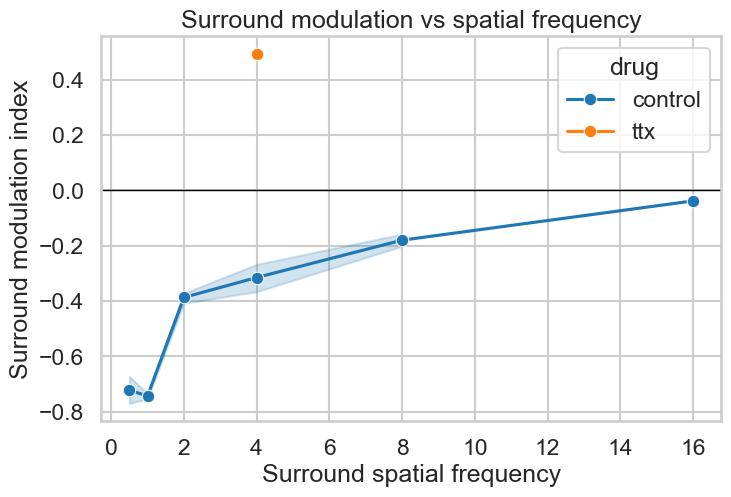

In [30]:
plt.figure(figsize=(8, 5))

sns.lineplot(
    data=smi_results,
    x="surround_sf",
    y="SMI",
    hue="drug",
    marker="o"
)

plt.axhline(0, color="black", lw=1)
plt.xlabel("Surround spatial frequency")
plt.ylabel("Surround modulation index")
plt.title("Surround modulation vs spatial frequency")
plt.show()


## SAVE FIGURES

any plot can be saved by adding this code before plt.show()

In [31]:
#plt.savefig(FIG_DIR / "my_figure_name.png", dpi=300, bbox_inches="tight")

In [32]:
##Checking the averaged trace
row = average_results.iloc[2]
row

file                        2026_05_14_0041.abf
drug                                    control
stimulus_type                   center_surround
center_sf                                   1.0
surround_sf                                 1.0
sweeps                                        1
clamp_mV                                    -70
stimID                                     56.0
notes                                       NaN
peak_inward_pA                       -96.082603
peak_outward_pA                       23.546301
mean_response_pA                      -4.203657
early_mean_response_pA                -3.569875
late_mean_response_pA                 -4.293948
charge_transfer_pA_s                 -33.628277
analysis_level                    average_trace
sweep                                       avg
baseline_mean_pA                      -30.87052
n_sweeps_averaged                             1
inward_mean_response_pA                4.203657
inward_peak_response_pA               96